In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [38]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import plot_tree
from sklearn.metrics import accuracy_score,precision_score,recall_score,classification_report,confusion_matrix,roc_auc_score
import warnings
warnings.filterwarnings('ignore')
from sklearn.datasets import load_breast_cancer


In [23]:
data = load_breast_cancer()


In [24]:
df = pd.DataFrame(data.data,columns = load_breast_cancer().feature_names)
df['target'] = data.target
df.head()


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


In [27]:
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size = 0.2,random_state = 42)
dt = DecisionTreeClassifier(max_depth = 5,criterion = 'gini')
dt.fit(x_train,y_train)
y_pred = dt.predict(x_test)

0.9473684210526315
0.9577464788732394
0.9577464788732394
              precision    recall  f1-score   support

           0       0.93      0.93      0.93        43
           1       0.96      0.96      0.96        71

    accuracy                           0.95       114
   macro avg       0.94      0.94      0.94       114
weighted avg       0.95      0.95      0.95       114

0.9439895185063871


<Axes: >

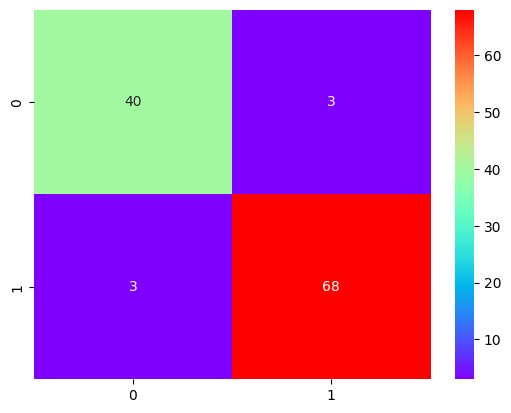

In [39]:
print(accuracy_score(y_test,y_pred))
print(precision_score(y_test,y_pred))
print(recall_score(y_test,y_pred))
print(classification_report(y_test,y_pred))
print(roc_auc_score(y_test,y_pred))
a = confusion_matrix(y_test,y_pred)
sns.heatmap(a,annot = True,cmap = 'rainbow')

In [ ]:
DECISION TREE CLASSIFIER FROM SCRATCH

In [42]:
from collections import Counter

class DecisionTreeClassifier:
    def __init__(self, max_depth=5, min_samples_split=2, min_samples_leaf=5):
        self.max_depth = max_depth
        self.min_samples_split = min_samples_split
        self.min_samples_leaf = min_samples_leaf
        self.tree = None

    def _gini(self, y):
        m = len(y)
        if m == 0:
            return 0
        counts = np.bincount(y)
        probs = counts / m
        return 1 - np.sum(probs ** 2)

    def _best_split(self, X, y):
        best_feature, best_thresh = None, None
        best_gini = float("inf")

        n_samples, n_features = X.shape

        for feature in range(n_features):
            values = np.sort(np.unique(X[:, feature]))

            thresholds = (values[:-1] + values[1:]) / 2

            for thresh in thresholds:
                left_mask = X[:, feature] <= thresh
                right_mask = ~left_mask

                y_left, y_right = y[left_mask], y[right_mask]

                if len(y_left) < self.min_samples_leaf or len(y_right) < self.min_samples_leaf:
                    continue

                gini = (
                    len(y_left) * self._gini(y_left) +
                    len(y_right) * self._gini(y_right)
                ) / n_samples

                if gini < best_gini:
                    best_gini = gini
                    best_feature = feature
                    best_thresh = thresh

        return best_feature, best_thresh

    
    def _build_tree(self, X, y, depth):
        n_samples = len(y)
        n_classes = len(set(y))
        if (
            depth >= self.max_depth or
            n_classes == 1 or
            n_samples < self.min_samples_split
        ):
            return Counter(y).most_common(1)[0][0]

        feature, thresh = self._best_split(X, y)

        if feature is None:
            return Counter(y).most_common(1)[0][0]

        left_mask = X[:, feature] <= thresh
        right_mask = ~left_mask

        left = self._build_tree(X[left_mask], y[left_mask], depth + 1)
        right = self._build_tree(X[right_mask], y[right_mask], depth + 1)

        return {
            "feature": feature,
            "threshold": thresh,
            "left": left,
            "right": right
        }

    def fit(self, X, y):
        self.tree = self._build_tree(X, y, 0)

    def _predict_one(self, x, tree):
        if not isinstance(tree, dict):
            return tree

        if x[tree["feature"]] <= tree["threshold"]:
            return self._predict_one(x, tree["left"])
        else:
            return self._predict_one(x, tree["right"])

    def predict(self, X):
        return np.array([self._predict_one(x, self.tree) for x in X])

0.956140350877193
0.9583333333333334
0.971830985915493
              precision    recall  f1-score   support

           0       0.95      0.93      0.94        43
           1       0.96      0.97      0.97        71

    accuracy                           0.96       114
   macro avg       0.96      0.95      0.95       114
weighted avg       0.96      0.96      0.96       114



<Axes: >

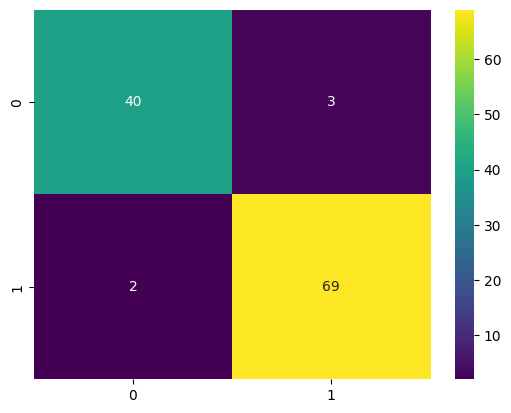

In [46]:
data = load_breast_cancer()
x,y = data.data,data.target
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size = 0.2,random_state = 42)
model = DecisionTreeClassifier(max_depth = 5,min_samples_leaf = 5)
model.fit(x_train,y_train)
y_pred = model.predict(x_test)
print(accuracy_score(y_test,y_pred))
print(precision_score(y_test,y_pred))
print(recall_score(y_test,y_pred))
print(classification_report(y_test,y_pred))
a = confusion_matrix(y_test,y_pred)
sns.heatmap(a,annot = True,cmap = 'viridis')